[Text(0.5, 0.8333333333333334, 'cerveja <= 5.5\nsquared_error = 9.772\nsamples = 15\nvalue = 5.817'),
 Text(0.25, 0.5, 'cerveja <= 3.5\nsquared_error = 3.126\nsamples = 7\nvalue = 2.979'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'squared_error = 0.637\nsamples = 4\nvalue = 1.812'),
 Text(0.375, 0.16666666666666666, 'squared_error = 2.216\nsamples = 3\nvalue = 4.533'),
 Text(0.75, 0.5, 'cerveja <= 7.5\nsquared_error = 2.372\nsamples = 8\nvalue = 8.3'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'squared_error = 0.142\nsamples = 3\nvalue = 6.467'),
 Text(0.875, 0.16666666666666666, 'squared_error = 0.484\nsamples = 5\nvalue = 9.4')]

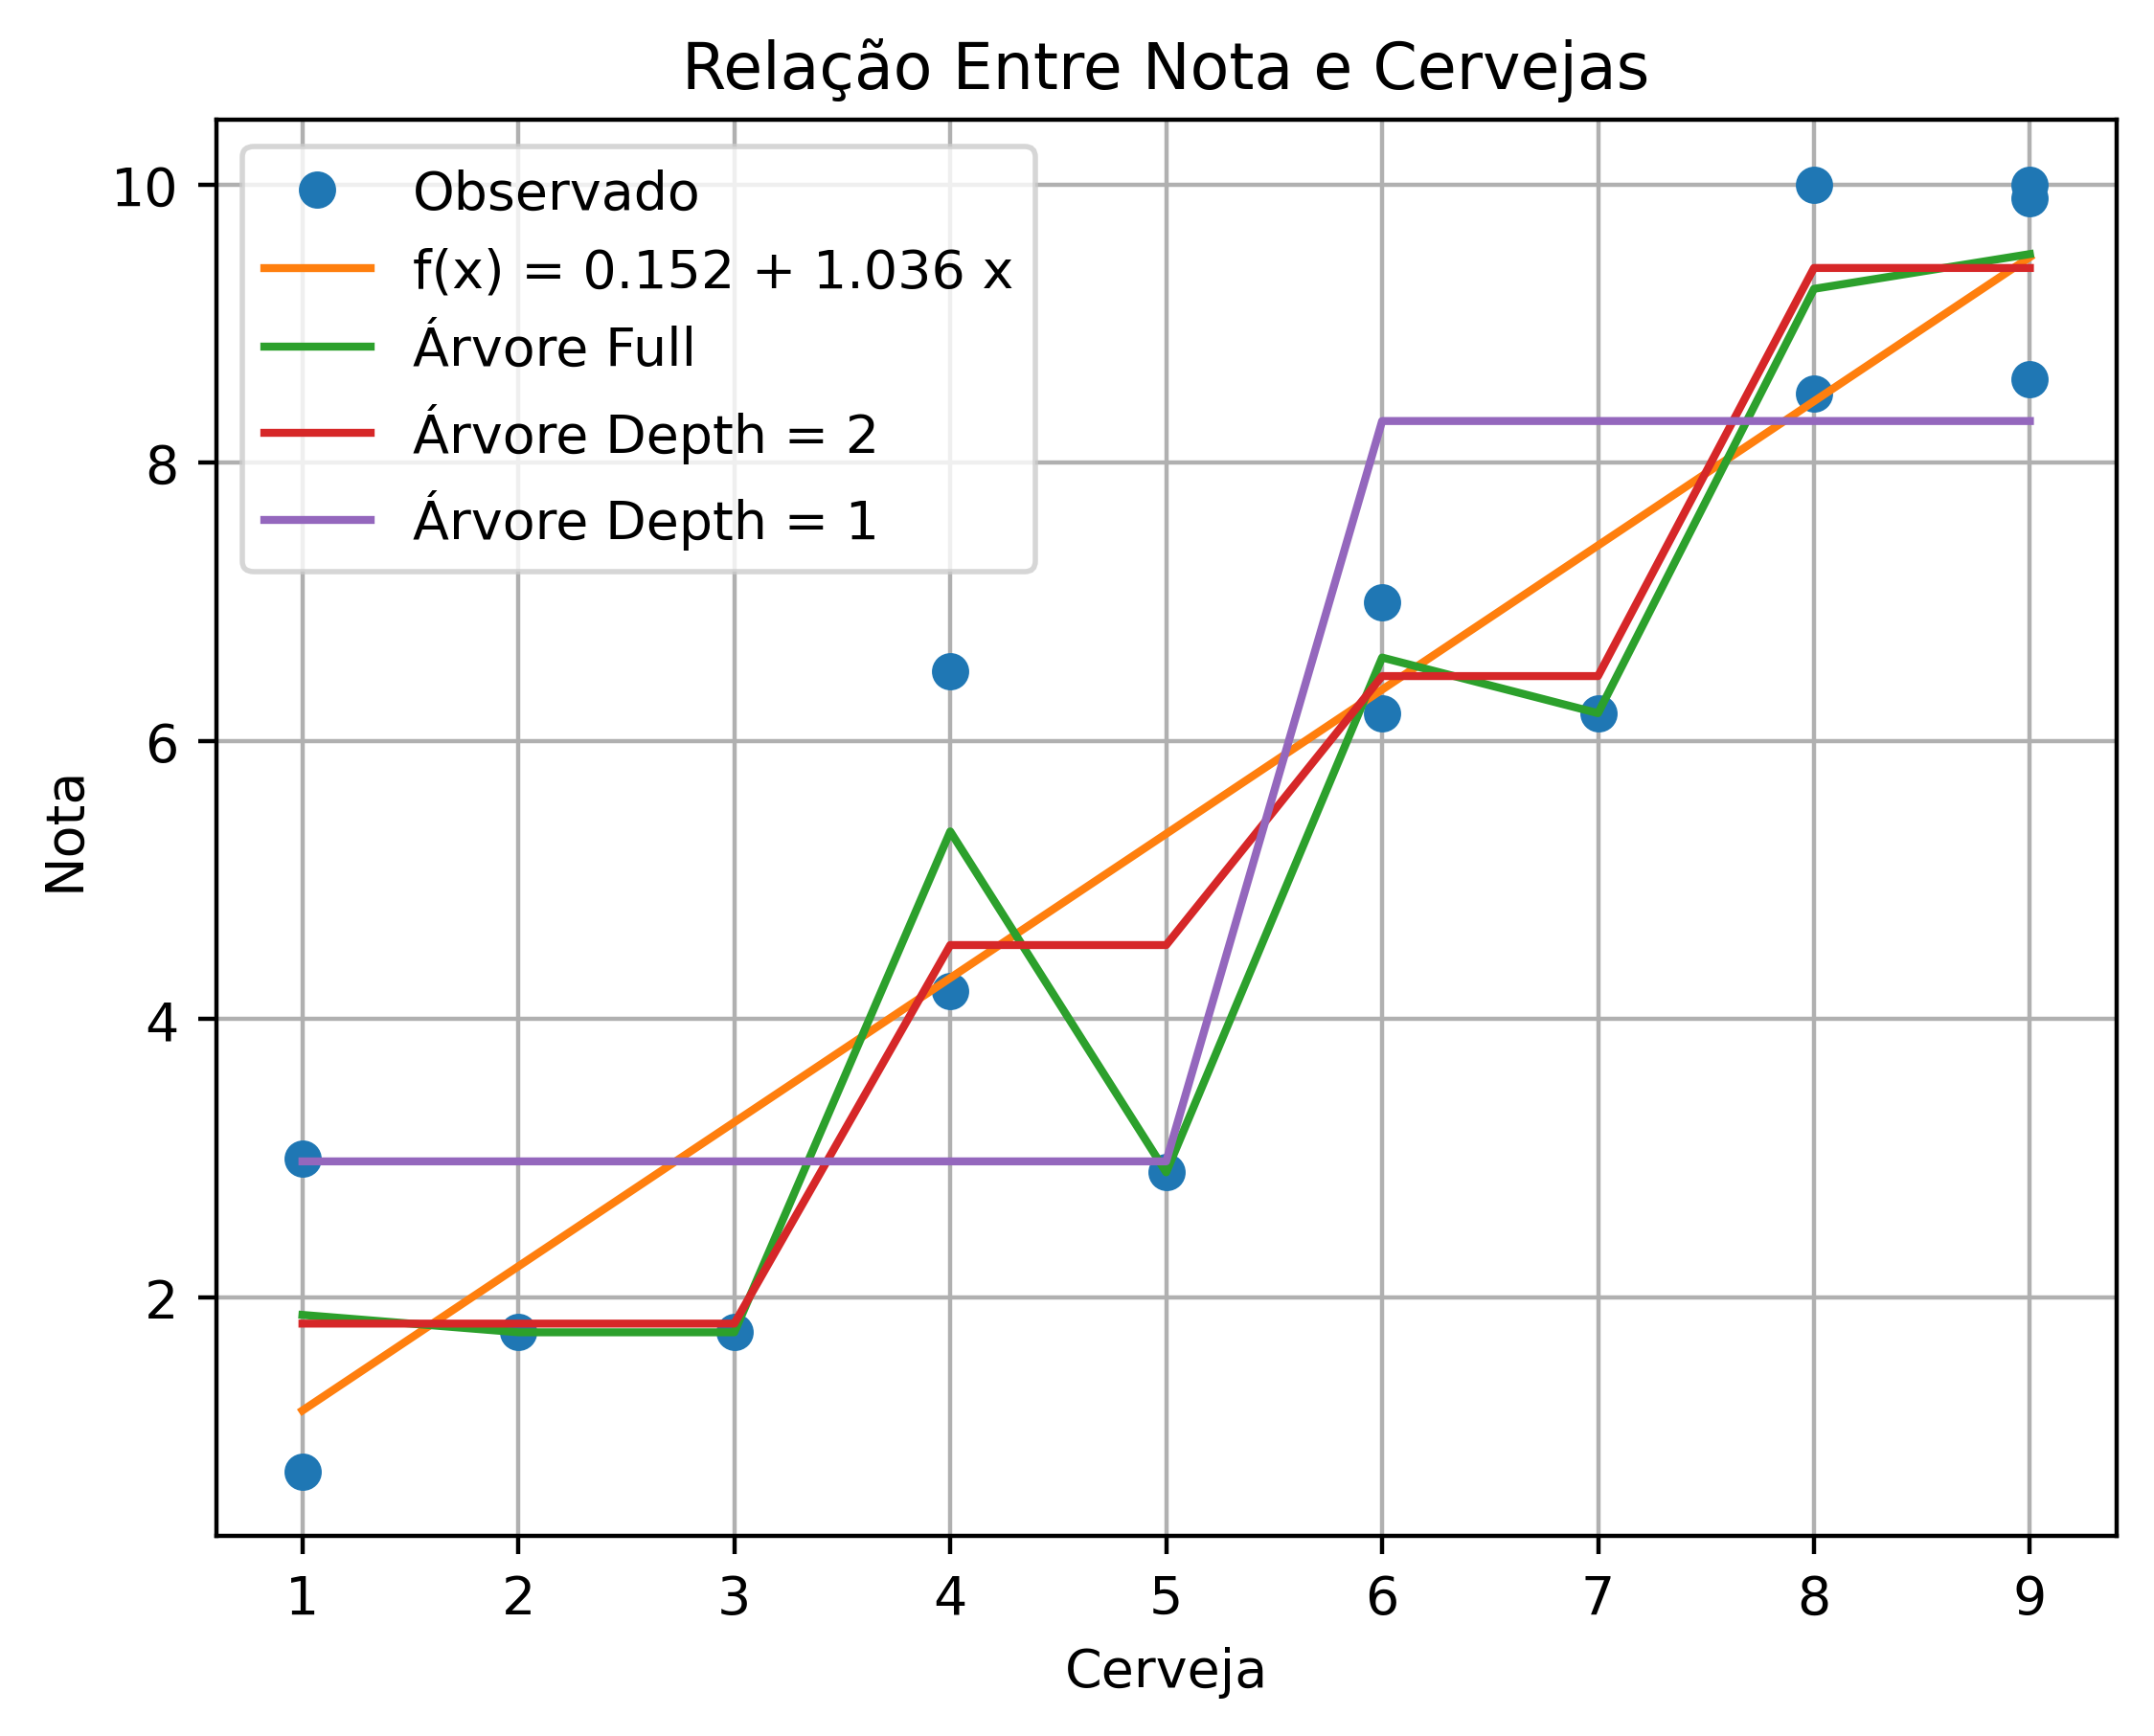

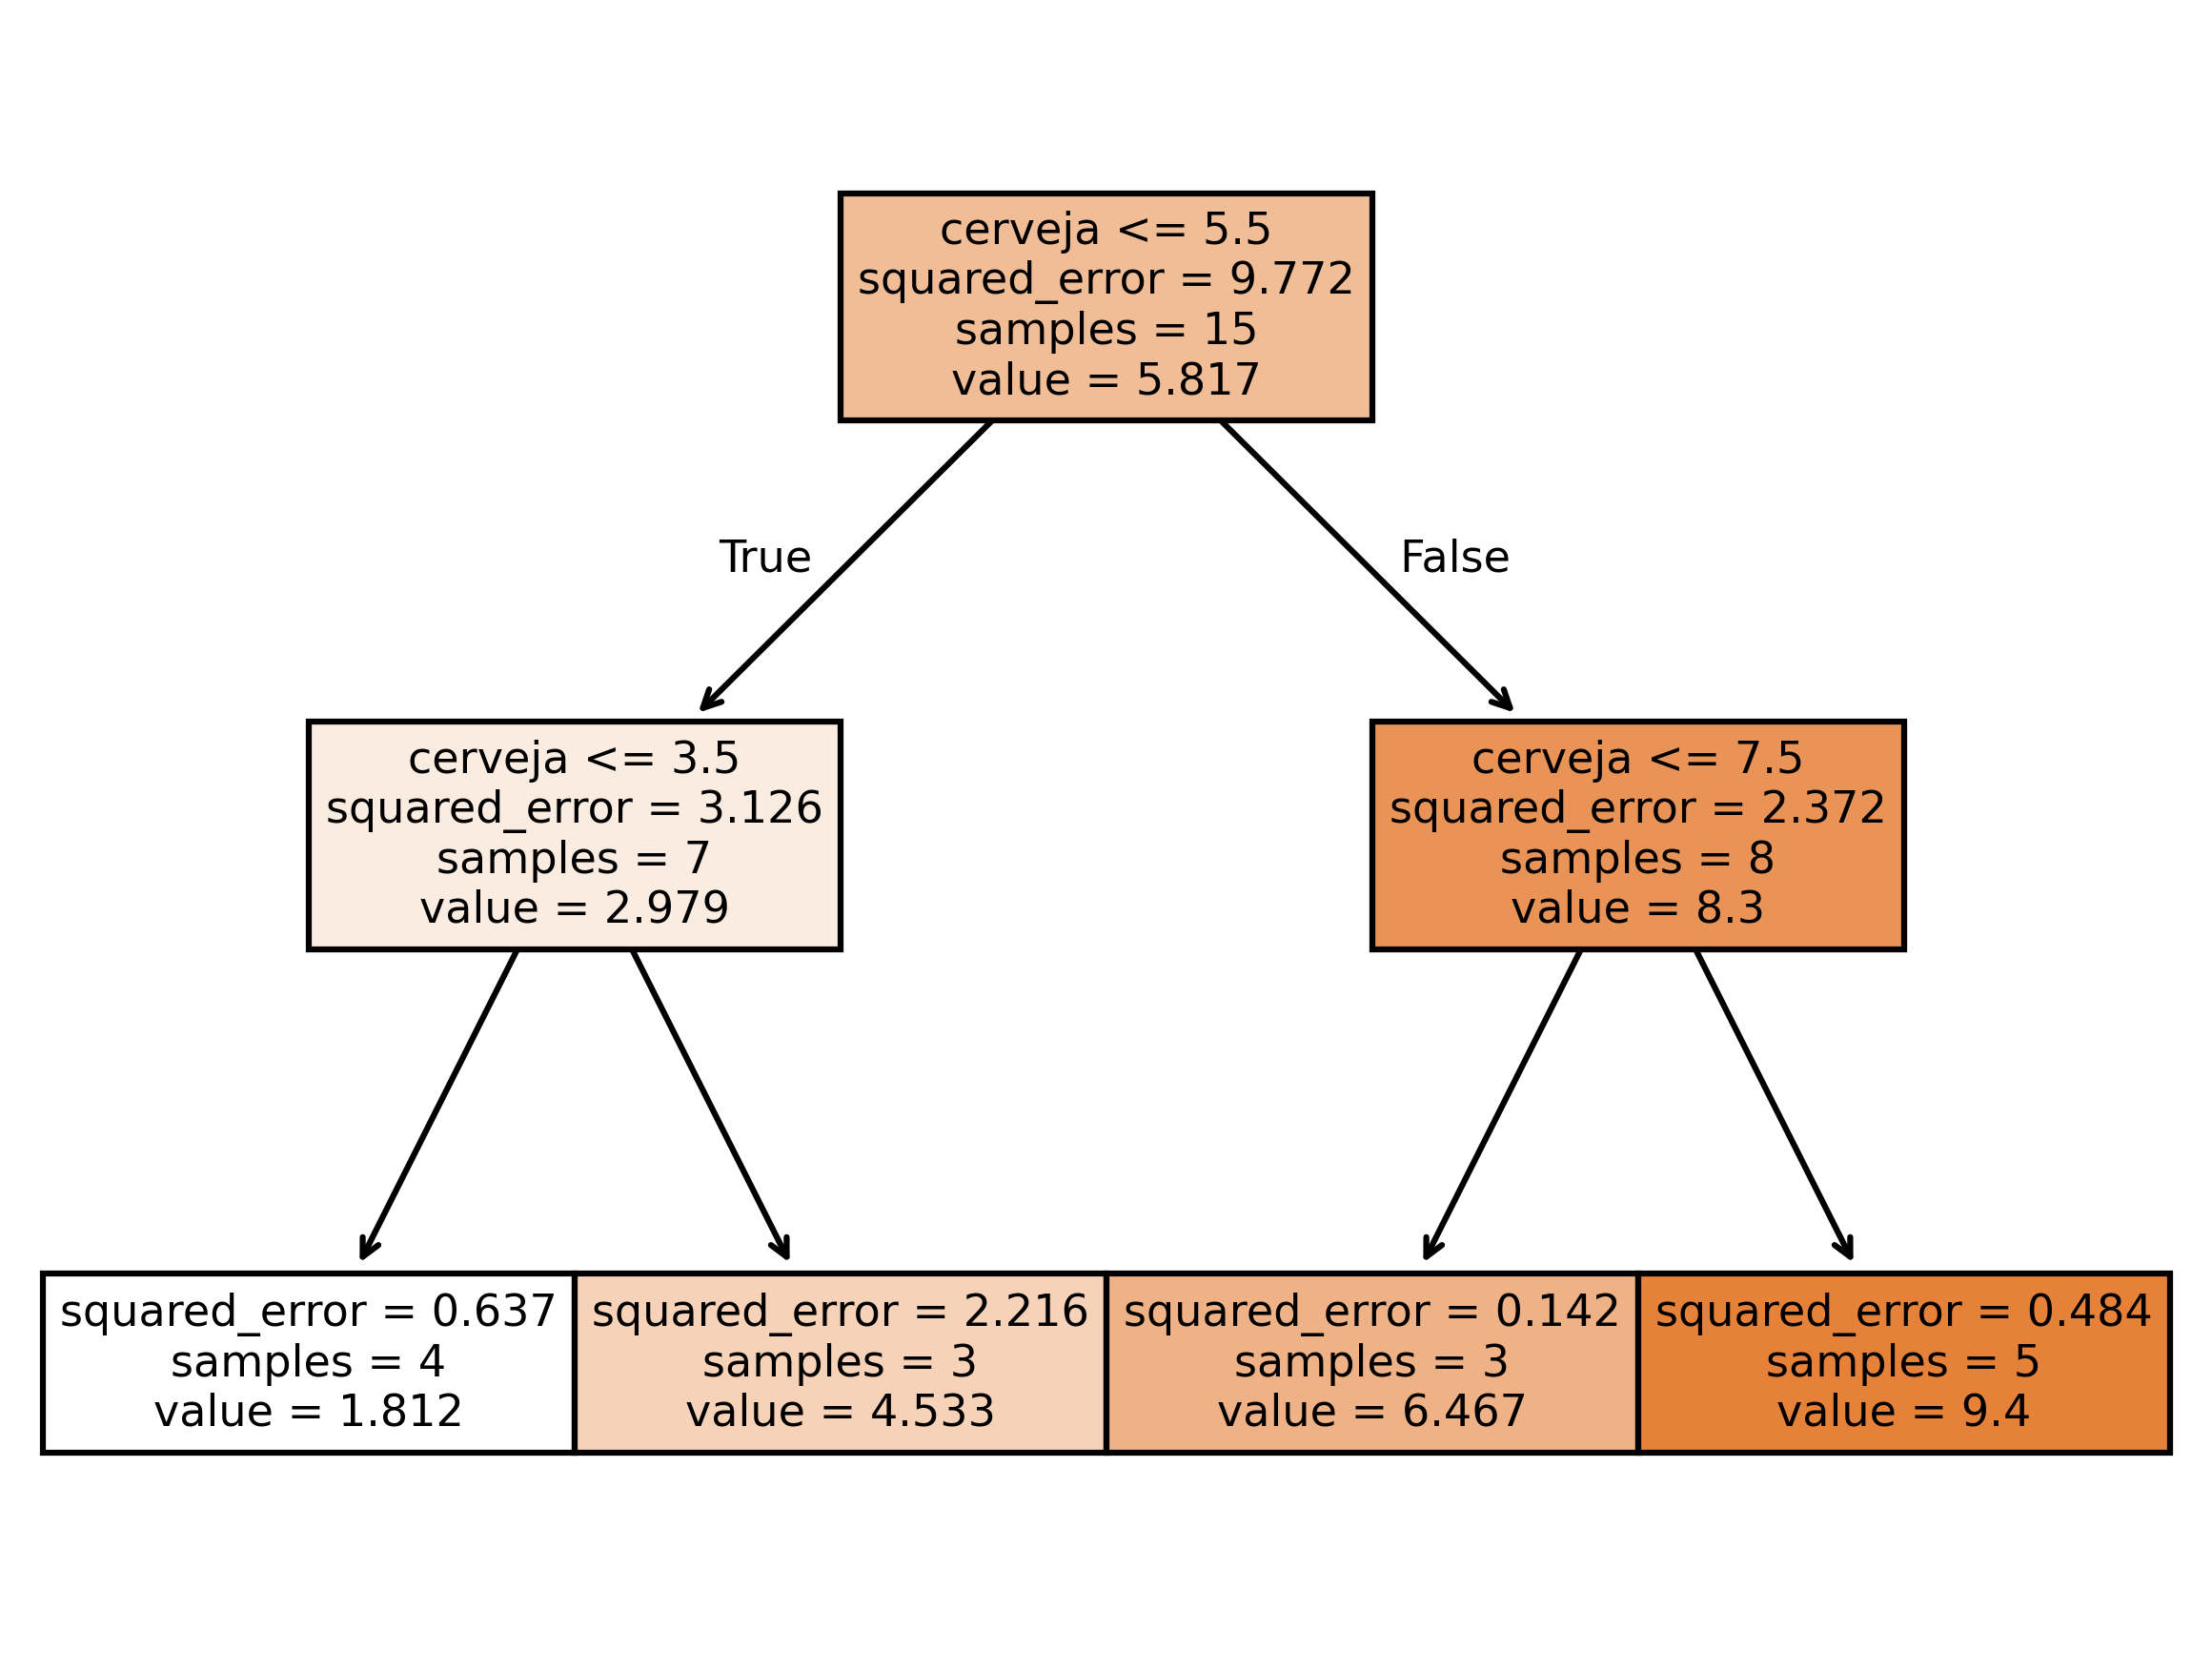

In [4]:
from sklearn import linear_model, tree
import pandas as pd


df = pd.read_excel('../data/dados_cerveja_nota.xlsx')

X = df[['cerveja']]     # X é uma Matriz, é um vetor bidimensional, com linhas e colunas
y = df['nota']          # y é um vetor

# Modelo
reg = linear_model.LinearRegression()

# O aprendizado - Algoritmo aprendendo com os dados
reg.fit(X, y)

a, b = reg.intercept_, reg.coef_[0]

predict_reg = reg.predict(X.drop_duplicates())

# Árvore completamente ajustada aos dados, provavelmente com overfitting
arvore_full = tree.DecisionTreeRegressor(random_state=42)
arvore_full.fit(X, y)

predict_arvore_full = arvore_full.predict(X.drop_duplicates())

arvore_d2 = tree.DecisionTreeRegressor(random_state=42, max_depth=2)
arvore_d2.fit(X, y)

predict_arvore_d2 = arvore_d2.predict(X.drop_duplicates())

arvore_d1 = tree.DecisionTreeRegressor(random_state=42, max_depth=1)
arvore_d1.fit(X, y)

predict_arvore_d1 = arvore_d1.predict(X.drop_duplicates())

import matplotlib.pyplot as plt

plt.figure(dpi=400)
# Plot relacionando variáveis x e y
plt.plot(X['cerveja'], y, 'o')
plt.grid(True)
plt.title("Relação Entre Nota e Cervejas")
plt.xlabel("Cerveja")
plt.ylabel('Nota')

# Plot da regressão Linear: Reta passando pelos pontos de variáveis de entrada X e previsão y
plt.plot(X.drop_duplicates()['cerveja'], predict_reg)

# Plot das Regressões com Árvores de Decisão
plt.plot(X.drop_duplicates()['cerveja'], predict_arvore_full)   # Sem limite de profundidade
plt.plot(X.drop_duplicates()['cerveja'], predict_arvore_d2) # Profundidade max é 2
plt.plot(X.drop_duplicates()['cerveja'], predict_arvore_d1) # Profundidade max é 3

# Legenda para cada elemento do gráfico
plt.legend(['Observado', f"f(x) = {a:.3f} + {b:.3f} x", 'Árvore Full', 'Árvore Depth = 2', 'Árvore Depth = 1'])

plt.figure(dpi=450)

tree.plot_tree(
    arvore_d2,
    feature_names=['cerveja'],
    filled=True
)